In [1]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
retail_sales=pd.read_csv("data.csv",encoding="latin1")
retail_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
retail_sales.shape

(541909, 8)

In [4]:
retail_sales.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
retail_sales.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# check missing value 

retail_sales.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [8]:
retail_sales.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# check the duplicate value

retail_sales.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [10]:
retail_sales.duplicated().sum()

np.int64(5268)

In [11]:
retail_sales = retail_sales.dropna(subset=['CustomerID'])

In [12]:
retail_sales.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
retail_sales.shape

(406829, 8)

In [14]:
retail_sales.duplicated().sum()

np.int64(5225)

In [15]:
# remove the duplicates

retail_sales = retail_sales.drop_duplicates()

In [16]:
retail_sales.duplicated().sum()

np.int64(0)

In [17]:
retail_sales.shape

(401604, 8)

In [18]:
# remove the cancelled order

retail_sales= retail_sales[~retail_sales['InvoiceNo'].str.contains('C')]

In [19]:
retail_sales.shape

(392732, 8)

In [20]:
# feature Engineering 

retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [21]:
# pandas ke andar function h  to_datetime  jo uske datatype ko datetime me convert krr deta h

retail_sales['InvoiceDate']=pd.to_datetime(retail_sales['InvoiceDate'])

In [22]:
retail_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [23]:
retail_sales['Month']  = retail_sales['InvoiceDate'].dt.month

In [24]:
retail_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12


In [25]:
retail_sales['year']  = retail_sales['InvoiceDate'].dt.year

In [26]:
retail_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010


In [27]:
retail_sales['Day']  = retail_sales['InvoiceDate'].dt.day_name()

In [28]:
retail_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,year,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday


In [29]:
retail_sales['Revenue'] = retail_sales['Quantity'] * retail_sales['UnitPrice']
retail_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,year,Day,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,Wednesday,20.34


In [30]:
# EDA exploratry data analysis

# total revenue

total_revenue = retail_sales["Revenue"].sum()
print("Total revenue:",total_revenue)

Total revenue: 8887208.894


In [31]:
# monthly sales

monthly_sales = retail_sales.groupby('Month')['Revenue'].sum()
print("Monthly Sales",monthly_sales)

Monthly Sales Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: Revenue, dtype: float64


In [32]:
# top 5 monthly sales 

monthly_sales = retail_sales.groupby('Month')['Revenue'].sum().sort_values(ascending=False).head(5)
print("Monthly Sales",monthly_sales)

Monthly Sales Month
11    1156205.610
12    1087613.170
10    1035642.450
9      950690.202
5      677355.150
Name: Revenue, dtype: float64


In [33]:
# daily trend (day wise sales) 

daily_sales = retail_sales.groupby('Day')['Revenue'].sum().sort_values(ascending=False)
print("Daily Trend",daily_sales)

Daily Trend Day
Thursday     1973015.730
Tuesday      1697733.801
Wednesday    1584283.830
Friday       1483080.811
Monday       1363604.401
Sunday        785490.321
Name: Revenue, dtype: float64


In [34]:
# count countries

retail_sales["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [35]:
retail_sales["Country"].nunique()

37

In [36]:
 # top 10 country

top_country = retail_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top Country",top_country)


Top Country Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


In [37]:
 # top 10 products

top_product = retail_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top Product",top_product)


Top Product Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


In [38]:
 # top 20 customers

top_customer = retail_sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(20)
print("Top Customer",top_customer)


Top Customer CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
16684.0     66653.56
14096.0     65164.79
13694.0     65039.62
15311.0     60632.75
13089.0     58762.08
17949.0     58510.48
15769.0     56252.72
15061.0     54534.14
14298.0     51527.30
14088.0     50491.81
Name: Revenue, dtype: float64


In [39]:
# repeated customer

repeated_customer = retail_sales['CustomerID'].value_counts()
print("Repeated Customer",repeated_customer)

Repeated Customer CustomerID
17841.0    7676
14911.0    5672
14096.0    5111
12748.0    4413
14606.0    2677
           ... 
17747.0       1
16737.0       1
18184.0       1
15313.0       1
13106.0       1
Name: count, Length: 4339, dtype: int64


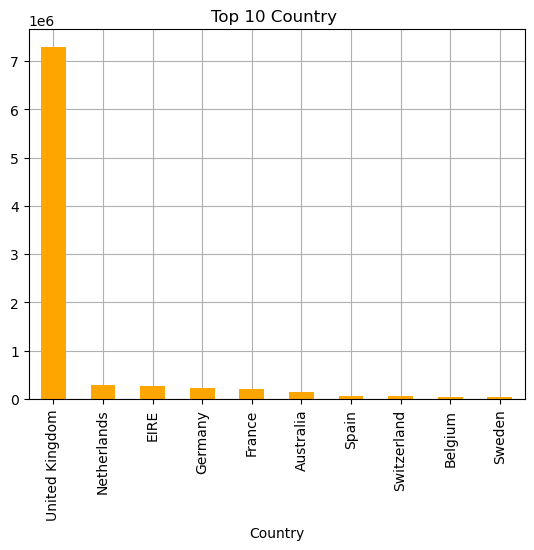

In [40]:
# data visualisation 

# Top 10 Country

top_country.plot(kind = 'bar',color = 'orange',zorder=2)        # 1e6 ----- > 1 exponent 6

plt.title("Top 10 Country ")

plt.grid()

plt.show()



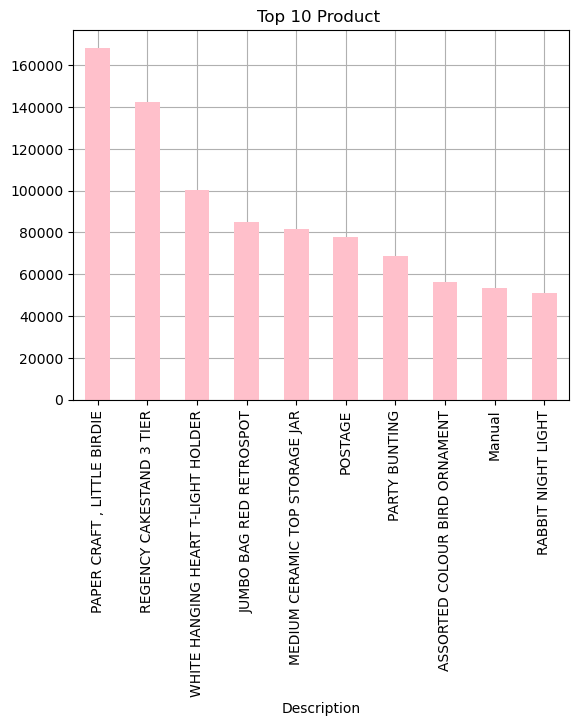

In [41]:
# Top 10 Product

top_product.plot(kind = 'bar',color = 'pink',zorder=2) 

plt.title("Top 10 Product ")

plt.grid()

plt.show()



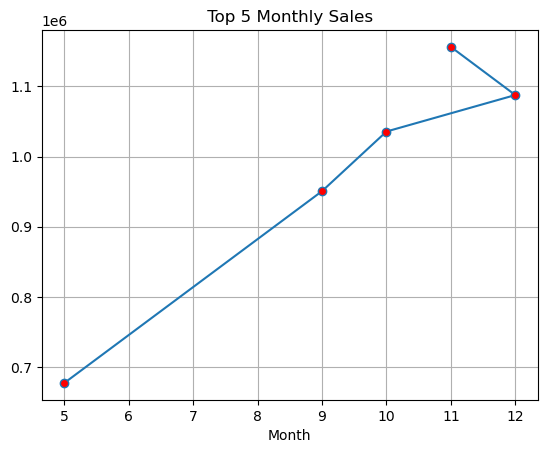

In [42]:
#  Top 5 Monthly Sales 

monthly_sales.plot(kind = 'line',marker ="o",markerfacecolor = "red") 

plt.title(" Top 5 Monthly Sales ")

plt.grid()

plt.show()






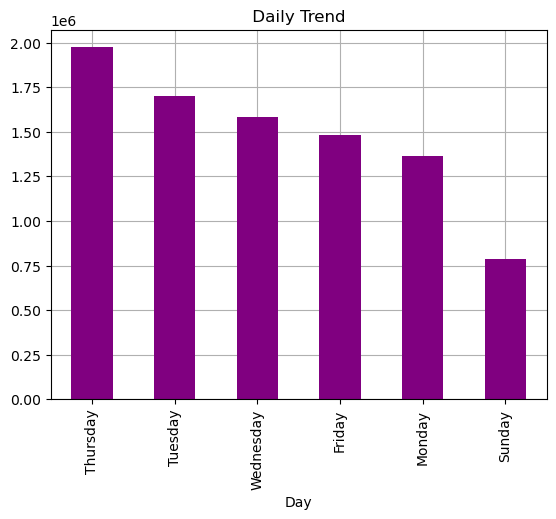

In [43]:
#  Daily Trend

daily_sales.plot(kind = 'bar',color = "purple",zorder = 2) 

plt.title(" Daily Trend ")

plt.grid()

plt.show()






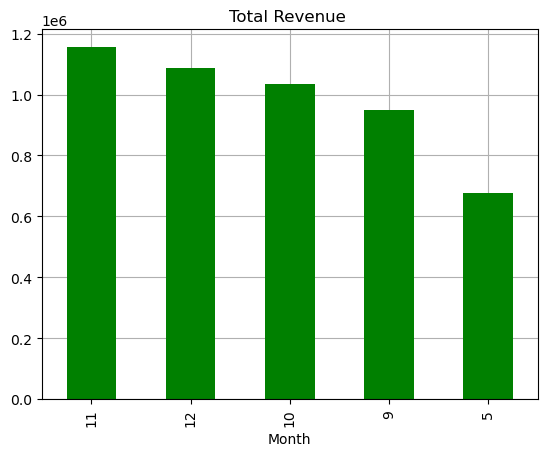

In [53]:
# Total Revenue

monthly_sales.plot(kind="bar",color = "green",zorder = 2) 

plt.title("Total Revenue ")

plt.grid()

plt.show()


In [ ]:
# Business insights

'''

1. Sabse zyada business UK se aata hai
UK se 72.8 lakh ka revenue aaya jabki doosre number ke desh (Netherlands) se sirf 2.85 lakh. 
Matlab company bohot zyada sirf UK pe depend kar rahi hai. Doosre countries mein business badhane ka mauka hai.

2. Thodi customers hi zyada revenue de rahe hain
Ek customer (ID 14646) akele 2.8 lakh ka order kar chuka hai. Ek customer (ID 17841) ne to 7,676 baar order kiya hai. 
Matlab kuch loyal customers hi business ka bada hissa hain — inhe special offers/rewards dene chahiye taaki wo bane rahein.

3. Zyadatar orders chhote hote hain
Data se pata chala ki zyadatar orders ki value kam hai, sirf kuch hi orders bade hote hain. 
Isliye combo offers ya "buy more, save more" jaisi schemes se order value badhayi ja sakti hai.

4. Saal ke aakhir mein sales badhti hai
August se November tak sales lagataar badhti gayi, November mein sabse zyada (1.15M) rahi December mein thoda kam hui. 
Isliye November ke aas-paas stock aur marketing pehle se tayyar rakhni chahiye.

5. Kuch products sabse zyada bikte hain
Gift aur decoration items (jaise light holder, cake stand, bunting) sabse zyada revenue laate hain. 
In products ka stock kabhi khatam nahi hona chahiye, aur inke saath milte-julte products bhi bechne chahiye.

6. Returns bhi dhyan dene layak hain
Data mein kuch orders negative quantity/UnitPrice ke hain, matlab wo returns ya cancellations hain. 
Ye alag se check karna chahiye ki kis product mein returns zyada ho rahe hain.

'''

In [ ]:
'''
💼 Interview mein 30-second explanation


“I performed an exploratory analysis of retail sales data using Python,Pandas and Matplotlib.The dataset contained over 541K records initially,
and after cleaning, around 392K records were analyzed. Total revenue was approximately 8.89 million. I identified the top-performing products,
analyzed monthly revenue trends and identified repeat customers. The analysis showed strong sales concentration during September to December 
and highlighted key products and customer segments that can support inventory planning, customer retention and data-driven business decisions.”

'''